# TropiCycloneNet — Startoff Notebook

This notebook supports you to start off with the **TropiCycloneNet Dataset (TCN_D)**.

It helps you:
1. download either the **test subset** or the **full dataset**
2. inspect the structure of **Data_1d, Data_3d, and Env-Data**
3. make **clean scientific tropical cyclone visualizations**
4. directions to work on with

---
## What this dataset is

TropiCycloneNet is a multimodal tropical cyclone dataset covering **1950–2023** across six major ocean basins. It contains:
- `Data_1d`: cyclone-center attributes such as longitude, latitude, pressure, wind
- `Data_3d`: gridded meteorological fields around the cyclone center
- `Env-Data`: structured environmental features

The official dataset page describes:
- full dataset: about **25.7 GB**
- test subset: about **3.34 GB**
- `Data_3d` covers a **20° × 20°** region centered on the storm
- spatial resolution: **0.25°**
- temporal resolution: **6-hourly**

## 0. Import packages

In [1]:
# CHANGED: UNCOMMENTED THE INSTALL LINE SO DEPENDENCIES ARE INSTALLED AUTOMATICALLY
!pip install -q gdown netCDF4 pandas numpy matplotlib cartopy seaborn xarray scipy

from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False

DATA_DIR = Path("data/tropicyclonenet")
DATA_DIR.mkdir(parents=True, exist_ok=True)

## 1. Official download options
The official dataset repository provides:
- **Full dataset** (~25.7 GB)
- **Test subset** (~3.34 GB)

The GitHub documentation also provides a `read_TCND.py` script to visualize examples.

### recommendation
Start with the **test subset**. It is much more realistic for classroom work.

In [2]:
# Google Drive file IDs from the official dataset page
GDRIVE_IDS = {
    "full_dataset": "1BUAab0OYyiArbraQHu2oMoj_jF-nNUxT",
    "test_subset": "1Xx2rzH6ztSGLTUR9EZkfDz5mQHsvhHsi",
}
GDRIVE_IDS

{'full_dataset': '1BUAab0OYyiArbraQHu2oMoj_jF-nNUxT',
 'test_subset': '1Xx2rzH6ztSGLTUR9EZkfDz5mQHsvhHsi'}

Run the below cell to get the ready to copy command for download the dataset !

In [3]:
def gdown_command(file_id, output_name):
    return f"gdown --fuzzy 'https://drive.google.com/file/d/{file_id}/view?usp=sharing' -O {output_name}"

print("Test subset:")
print(gdown_command(GDRIVE_IDS["test_subset"], DATA_DIR / "TCND_test.zip"))
print("\nFull dataset:")
print(gdown_command(GDRIVE_IDS["full_dataset"], DATA_DIR / "TCND_full.zip"))

Test subset:
gdown --fuzzy 'https://drive.google.com/file/d/1Xx2rzH6ztSGLTUR9EZkfDz5mQHsvhHsi/view?usp=sharing' -O data/tropicyclonenet/TCND_test.zip

Full dataset:
gdown --fuzzy 'https://drive.google.com/file/d/1BUAab0OYyiArbraQHu2oMoj_jF-nNUxT/view?usp=sharing' -O data/tropicyclonenet/TCND_full.zip


### CHANGED: ADDED ACTUAL DOWNLOAD CELLS BELOW (PREVIOUSLY THE NOTEBOOK ONLY PRINTED THE COMMANDS BUT NEVER EXECUTED THEM)

Run the cells below to download **both** the test subset and the full dataset. If you only want the test subset, skip the full dataset cell.

In [4]:
# CHANGED: ACTUALLY DOWNLOAD THE TEST SUBSET (~3.34 GB)
# (PREVIOUSLY THIS WAS ONLY SHOWN AS A COPY-PASTE COMMAND, NOT EXECUTED)
!gdown --fuzzy "https://drive.google.com/file/d/1Xx2rzH6ztSGLTUR9EZkfDz5mQHsvhHsi/view?usp=sharing" -O data/tropicyclonenet/TCND_test.zip

Downloading...
From (original): https://drive.google.com/uc?id=1Xx2rzH6ztSGLTUR9EZkfDz5mQHsvhHsi
From (redirected): https://drive.google.com/uc?id=1Xx2rzH6ztSGLTUR9EZkfDz5mQHsvhHsi&confirm=t&uuid=3c97da8c-3b60-4059-a2fb-77cf5f203d59
To: /Users/yasminakhmedova/Desktop/ICL/2 Semester/Climate Change/Group Project/data/tropicyclonenet/TCND_test.zip
  0%|                                               | 0.00/3.59G [00:00<?, ?B/s]

  0%|                                      | 2.62M/3.59G [00:00<02:21, 25.4MB/s]

  0%|                                      | 6.29M/3.59G [00:00<02:00, 29.8MB/s]

  0%|                                      | 9.96M/3.59G [00:00<01:54, 31.2MB/s]

  0%|▏                                     | 13.1M/3.59G [00:00<02:22, 25.1MB/s]

...

100%|█████████████████████████████████████▉| 3.58G/3.59G [06:16<00:00, 16.0MB/s]

100%|█████████████████████████████████████▉| 3.58G/3.59G [06:16<00:00, 16.3MB/s]

100%|█████████████████████████████████████▉| 3.58G/3.59G [06:16<00:00, 15.2MB/s]

100%|█████████████████████████████████████▉| 3.58G/3.59G [06:16<00:00, 13.7MB/s]

100%|██████████████████████████████████████| 3.59G/3.59G [06:17<00:00, 9.51MB/s]


In [5]:
# CHANGED: ACTUALLY DOWNLOAD THE FULL DATASET (~25.7 GB)
# SKIP THIS CELL IF YOU ONLY NEED THE TEST SUBSET
!gdown --fuzzy "https://drive.google.com/file/d/1BUAab0OYyiArbraQHu2oMoj_jF-nNUxT/view?usp=sharing" -O data/tropicyclonenet/TCND_full.zip

Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1BUAab0OYyiArbraQHu2oMoj_jF-nNUxT

but Gdown can't. Please check connections and permissions.


## 2. Inspect folder structure

After extraction, first inspect whether the archive contains:
- `Data_1d/`
- `Data_3d/`
- `Env-Data/`

That immediately tells students how multimodality is organized.

In [6]:
import zipfile

def unzip_file(zip_path, extract_dir=None):
    zip_path = Path(zip_path)
    if extract_dir is None:
        extract_dir = zip_path.with_suffix("")
    extract_dir = Path(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print(f"Extracted to {extract_dir}")
    return extract_dir

def print_tree(root, max_depth=2, prefix=""):
    root = Path(root)
    if not root.exists():
        print(f"Missing path: {root}")
        return
    for p in sorted(root.iterdir()):
        print(prefix + p.name + ("/" if p.is_dir() else ""))
        if p.is_dir() and max_depth > 0:
            print_tree(p, max_depth=max_depth-1, prefix=prefix + "    ")

# CHANGED: UNCOMMENTED THE UNZIP AND PRINT_TREE CALLS (WERE PREVIOUSLY COMMENTED OUT)
unzip_file(DATA_DIR / "TCND_test.zip", DATA_DIR / "TCND_test")
print_tree(DATA_DIR / "TCND_test", max_depth=2)

Extracted to data/tropicyclonenet/TCND_test
.DS_Store
TCND_test/
    .DS_Store
    Data1D/
        .DS_Store
        EP/
        NA/
        NI/
        SI/
        SP/
        WP/
    Data3D/
        .DS_Store
        EP/
        NA/
        NI/
        SI/
        SP/
        WP/
    Env-Data/
        .DS_Store
        EP/
        NA/
        NI/
        SI/
        SP/
        WP/


In [7]:
# CHANGED: ADDED UNZIP FOR THE FULL DATASET
# SKIP THIS CELL IF YOU ONLY DOWNLOADED THE TEST SUBSET
unzip_file(DATA_DIR / "TCND_full.zip", DATA_DIR / "TCND_full")
print_tree(DATA_DIR / "TCND_full", max_depth=2)

FileNotFoundError: [Errno 2] No such file or directory: 'data/tropicyclonenet/TCND_full.zip'

In [8]:
def scan_files(root):
    root = Path(root)
    rows = []
    for p in root.rglob("*"):
        if p.is_file():
            rows.append({
                "path": str(p),
                "suffix": p.suffix.lower(),
                "size_mb": round(p.stat().st_size / 1024**2, 3)
            })
    return pd.DataFrame(rows).sort_values(["suffix", "path"]).reset_index(drop=True)

# CHANGED: UNCOMMENTED THE SCAN_FILES CALL (WAS PREVIOUSLY COMMENTED OUT)
files_df = scan_files(DATA_DIR / "TCND_test")
files_df.head(100)

,path,suffix,size_mb
0,data/tropicyclonenet/TCND_test/.DS_Store,,0.006
1,data/tropicyclonenet/TCND_test/TCND_test/.DS_S...,,0.006
2,data/tropicyclonenet/TCND_test/TCND_test/Data1...,,0.006
3,data/tropicyclonenet/TCND_test/TCND_test/Data1...,,0.006
4,data/tropicyclonenet/TCND_test/TCND_test/Data3...,,0.006
...,...,...,...
95,data/tropicyclonenet/TCND_test/TCND_test/Data3...,.nc,0.335
96,data/tropicyclonenet/TCND_test/TCND_test/Data3...,.nc,0.335
97,data/tropicyclonenet/TCND_test/TCND_test/Data3...,.nc,0.335
98,data/tropicyclonenet/TCND_test/TCND_test/Data3...,.nc,0.335


## 3. Reading patterns

The official docs suggest using `read_TCND.py` with:
`python read_TCND.py dataset_path TC_name TC_date area train_val_test`

For simple loading as startoff, it is useful to add a more explicit inspection workflow:
- identify tabular files in `Data_1d`
- identify gridded files in `Data_3d`
- inspect environmental feature files in `Env-Data`

In [9]:
def preview_tabular(path, n=5):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path, nrows=n)
    elif path.suffix.lower() in [".txt"]:
        return pd.read_csv(path, sep=None, engine="python", nrows=n)
    elif path.suffix.lower() in [".parquet"]:
        return pd.read_parquet(path).head(n)
    else:
        raise ValueError(f"Unsupported tabular preview: {path.suffix}")

In [10]:
def guess_tc_columns(df):
    rename = {}
    for c in df.columns:
        low = c.lower()
        if low in ["lat", "latitude"]:
            rename[c] = "latitude"
        elif low in ["lon", "longitude", "long"]:
            rename[c] = "longitude"
        elif "wind" in low:
            rename[c] = "wind"
        elif "press" in low:
            rename[c] = "pressure"
        elif "time" in low or "date" in low:
            rename[c] = "time"
        elif "name" in low:
            rename[c] = "tc_name"
    return df.rename(columns=rename)

## 4. Scientific visualization helpers

These are tailored to cyclone data:
- track maps
- intensity-time plots
- basin summaries
- storm-centered field plots

In [11]:
def plot_track(df, title="Tropical cyclone track", basin=None):
    df = guess_tc_columns(df.copy())
    if basin is not None and "basin" in df.columns:
        df = df[df["basin"] == basin]
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        df = df.sort_values("time")

    if HAS_CARTOPY:
        fig = plt.figure(figsize=(10,5))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
        ax.plot(df["longitude"], df["latitude"], "-o", ms=3, transform=ccrs.PlateCarree())
        ax.set_title(title, weight="bold")
    else:
        fig, ax = plt.subplots(figsize=(10,5))
        ax.plot(df["longitude"], df["latitude"], "-o", ms=3)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_title(title, weight="bold")
        ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig

def plot_intensity_time(df, wind_col="wind", pressure_col="pressure"):
    df = guess_tc_columns(df.copy())
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        df = df.sort_values("time")

    fig, ax1 = plt.subplots(figsize=(11,4))
    if wind_col in df.columns:
        ax1.plot(df["time"], df[wind_col], label="Wind")
        ax1.set_ylabel("Wind")
    if pressure_col in df.columns:
        ax2 = ax1.twinx()
        ax2.plot(df["time"], df[pressure_col], "--", label="Pressure")
        ax2.set_ylabel("Pressure")
    ax1.set_title("Storm intensity evolution", weight="bold")
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    return fig

def plot_basin_counts(df, basin_col="basin"):
    fig, ax = plt.subplots(figsize=(7,4))
    df[basin_col].value_counts().sort_values(ascending=False).plot.bar(ax=ax)
    ax.set_title("Cyclone counts by basin", weight="bold")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    return fig

## 5. Example storm-centered grid visualization

The official description says `Data_3d` includes:
- geopotential height (you can learn more about geopotential height [here](https://www.weather.gov/source/zhu/ZHU_Training_Page/Miscellaneous/Heights_Thicknesses/thickness_temperature.htm#GEOPOTENTIAL))
- U and V wind components
- pressure levels 200, 500, 850, 925 hPa 
- SST

If your `Data_3d` files are NetCDF-like, the template below is a good starting point.

Dataset Variables:
 ['u', 'v', 'z', 'sst']
Coordinates:
 ['time', 'pressure_level', 'latitude', 'longitude']


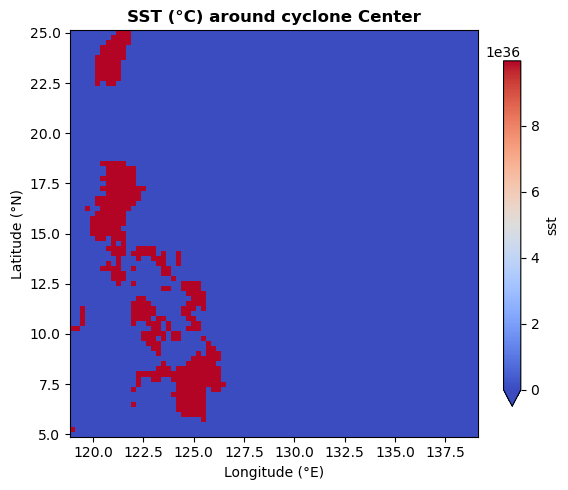

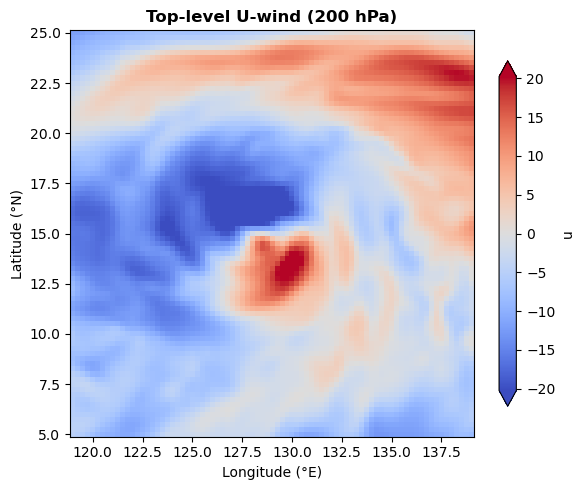

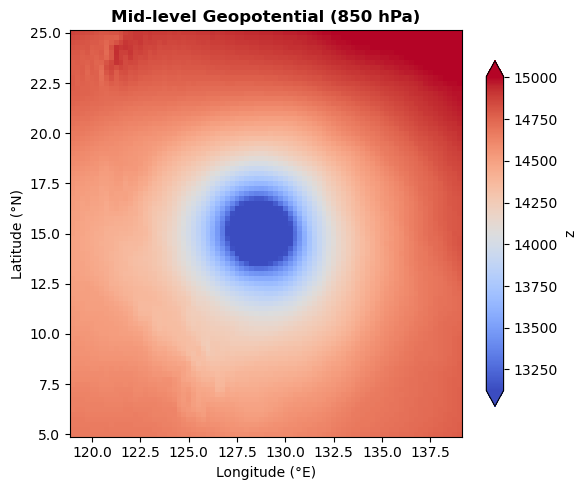

In [12]:
try:
    import xarray as xr
except Exception:
    xr = None

def plot_storm_field(da, title=None, cmap="coolwarm", figsize=(6,5)):
    fig, ax = plt.subplots(figsize=figsize)
    da.plot(ax=ax, cmap=cmap, robust=True, cbar_kwargs={"shrink":0.85})
    ax.set_title(title or str(da.name), weight="bold")
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    plt.tight_layout()
    return fig

# Let's inspect an actual file as an example
nc_file = "data/tropicyclonenet/TCND_test/TCND_test/Data3D/WP/2018/MANGKHUT/TCND_MANGKHUT_2018091312_sst_z_u_v.nc"
if xr is not None and Path(nc_file).exists():
    ds3d = xr.open_dataset(nc_file)
    print("Dataset Variables:\n", list(ds3d.data_vars))
    print("Coordinates:\n", list(ds3d.coords))
    
    # 1) SST has only spatial dimensions (latitude, longitude) and no 'time'
    fig_sst = plot_storm_field(ds3d["sst"], "SST (°C) around cyclone Center")
    
    # 2) U, V, Z have dimensions (time, pressure_level, latitude, longitude)
    # Select the first time slice, and pressure_level=0 (e.g. 200 hPa level)
    fig_u = plot_storm_field(ds3d["u"].isel(time=0, pressure_level=0), "Top-level U-wind (200 hPa)")
    
    # Select pressure_level=2 (e.g. 850 hPa level)
    fig_z = plot_storm_field(ds3d["z"].isel(time=0, pressure_level=2), "Mid-level Geopotential (850 hPa)")


## 6. Suggested project directions

### A — Track forecasting vs intensity forecasting
One may argue whether the same input modalities help both tasks equally, or whether track and intensity need different information.

### B — Basin generalization
Train on one basin or a subset of basins, then test transfer to another basin:
- Atlantic → Western Pacific
- Western Pacific → Indian Ocean

### C — Environmental precursors of rapid intensification
Use `Env-Data` and `Data_3d` to study which and how environmental conditions precede sharp increases in wind speed. You can even predict the next state, intensity growth or the timing of the next sharp increase.

### D — Multimodal fusion ablation
Compare:
- `Data_1d` only
- `Data_3d` only
- `Env-Data` only
- fused models

## 7. extra notes / comments

TropiCycloneNet is scientifically engaging, especially for the interest in hazards and extremes.

It works very well if you want **extreme-event, multimodal, time series, and spatiotemporal** projects.

## 8. Generate and Display GIF Animation

The following code creates a GIF animation across time steps for the MANGKHUT cyclone using the `Data_3d` NetCDF files, similar to the tracking animations seen on the project's repository. We will compute the wind speed at 850 hPa (mid-level) from the `u` and `v` components and plot it frame-by-frame.

In [13]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display, Image, HTML

def create_tc_animation(data_dir, output_gif="tc_animation.gif", fps=10):
    nc_files = sorted(glob.glob(f"{data_dir}/*.nc"))
    if not nc_files:
        print(f"No .nc files found in {data_dir}")
        return None
    
    print(f"Found {len(nc_files)} files. Generating animation...")
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Initialize first frame
    ds = xr.open_dataset(nc_files[0])
    # Try calculating wind speed at 850 hPa (index 2 for pressure_level)
    u_val = ds["u"].isel(time=0, pressure_level=2).values
    v_val = ds["v"].isel(time=0, pressure_level=2).values
    wind_spd = np.sqrt(u_val**2 + v_val**2)

    img = ax.imshow(wind_spd, cmap="viridis", origin="lower")
    plt.colorbar(img, ax=ax, label="Wind speed (m/s)")
    ax.set_xlabel("Longitude index")
    ax.set_ylabel("Latitude index")

    # Adding text for the timestamp
    title_text = ax.set_title("", weight="bold")
    
    def animate(i):
        ds_frame = xr.open_dataset(nc_files[i])
        u_f = ds_frame["u"].isel(time=0, pressure_level=2).values
        v_f = ds_frame["v"].isel(time=0, pressure_level=2).values
        wind_spd_f = np.sqrt(u_f**2 + v_f**2)
        img.set_array(wind_spd_f)
        
        # Extract Datetime from filename
        fname = os.path.basename(nc_files[i])
        date_str = fname.split('_')[2] # E.g., 2018091312
        title_text.set_text(f"Wind Speed (850 hPa) - {date_str[:8]} {date_str[8:]}:00")
        
        ds_frame.close()
        return [img, title_text]
    
    anim = animation.FuncAnimation(fig, animate, frames=len(nc_files), interval=1000/fps, blit=True)
    anim.save(output_gif, writer="pillow", fps=fps)
    plt.close(fig) # Prevent duplicate static plot in output
    print(f"Saved {output_gif}")
    
    return output_gif

# Directory for MANGKHUT
mangkhut_dir = "data/tropicyclonenet/TCND_test/TCND_test/Data3D/WP/2018/MANGKHUT"
gif_path = create_tc_animation(mangkhut_dir, "mangkhut_anim.gif", fps=8)

if gif_path:
    # Display the GIF inside the notebook
    display(HTML(f'<img src="{gif_path}" style="width:600px; height:auto;" />'))

Found 43 files. Generating animation...


Saved mangkhut_anim.gif


## 9. Tracking the Cyclone over a Map

While generating an animation frame by frame is nice, tracing the track on a geographical map is much more insightful, similar to how true satellite tracking looks. We can use `Cartopy` to plot the coastlines and overlay the wind speed patch at the exact location along with its path!

In [14]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display, HTML

# Only run if Cartopy is available
if HAS_CARTOPY:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    def create_mapped_tc_animation(data_dir, output_gif="tc_mapped_animation.gif", fps=7):
        nc_files = sorted(glob.glob(f"{data_dir}/*.nc"))
        if not nc_files: return None
        
        # 1. Compute bounds
        lons, lats, tc_lons, tc_lats = [], [], [], []
        for f in nc_files:
            with xr.open_dataset(f) as ds:
                lons.extend([ds['longitude'].min().values, ds['longitude'].max().values])
                lats.extend([ds['latitude'].min().values, ds['latitude'].max().values])
                
                # Center index is the storm's exact location
                tc_lon = ds['longitude'][len(ds['longitude']) // 2].values
                tc_lat = ds['latitude'][len(ds['latitude']) // 2].values
                tc_lons.append(tc_lon)
                tc_lats.append(tc_lat)

        extent = [min(lons)-2, max(lons)+2, min(lats)-2, max(lats)+2]
        
        # 2. Setup Aesthetic Base Plot
        plt.style.use('dark_background') # Give it a sleek dark theme
        fig = plt.figure(figsize=(10, 6), dpi=120)
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        
        # Apply strict professional aesthetic background
        ax.set_facecolor('#112233') # Ocean
        land_feature = cfeature.NaturalEarthFeature(category='physical', name='land', scale='50m', facecolor='#223344')
        ax.add_feature(land_feature, zorder=1)
        ax.coastlines(linewidth=0.8, color='#556677', zorder=2)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='#556677', zorder=2)
        
        # Semi-transparent gridlines
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.3, color='white', linestyle='--', zorder=3)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'color': 'lightgray', 'size': 9}
        gl.ylabel_style = {'color': 'lightgray', 'size': 9}
        
        # Title box
        title_text = ax.text(0.02, 0.95, "", transform=ax.transAxes, color='white', 
                             fontsize=12, weight='bold', bbox=dict(facecolor='black', alpha=0.6, edgecolor='none'), zorder=10)
        
        # Dynamic track line with glowing scatter
        track_line, = ax.plot([], [], '-', color='cyan', linewidth=2, alpha=0.8, transform=ccrs.PlateCarree(), zorder=5)
        track_points = ax.scatter([], [], s=30, color='white', edgecolors='cyan', zorder=6, transform=ccrs.PlateCarree())
        current_point = ax.scatter([], [], s=80, color='red', edgecolors='white', zorder=7, transform=ccrs.PlateCarree())
        
        # Set up a dummy pcolormesh specifically to generate ONE neat horizontal colorbar
        dummy_z = np.zeros((2, 2))
        dummy_lons = np.array([[extent[0], extent[1]], [extent[0], extent[1]]])
        dummy_lats = np.array([[extent[2], extent[2]], [extent[3], extent[3]]])
        dummy_mesh = ax.pcolormesh(dummy_lons, dummy_lats, dummy_z, cmap="magma", 
                                   vmin=0, vmax=50, transform=ccrs.PlateCarree(), visible=False, zorder=0)
        
        # Add a sleek, small horizontal colorbar at the bottom right
        cax = fig.add_axes([0.65, 0.15, 0.22, 0.02]) # [left, bottom, width, height]
        cbar = plt.colorbar(dummy_mesh, cax=cax, orientation='horizontal')
        cbar.set_label("Wind Speed (m/s)", color='white', size=10, weight='bold')
        cbar.ax.tick_params(colors='white', labelsize=9)
        cbar.outline.set_edgecolor('#556677')
        
        pmesh = [None]
        
        def animate(i):
            if pmesh[0] is not None:
                pmesh[0].remove()
                
            with xr.open_dataset(nc_files[i]) as ds_frame:
                u_f = ds_frame["u"].isel(time=0, pressure_level=2).values
                v_f = ds_frame["v"].isel(time=0, pressure_level=2).values
                w_spd_f = np.sqrt(u_f**2 + v_f**2)

                lon_f, lat_f = ds_frame['longitude'].values, ds_frame['latitude'].values
                lon_f_2d, lat_f_2d = np.meshgrid(lon_f, lat_f)
                
                # Plot the cyclone wind mesh using Magma glow
                pmesh[0] = ax.pcolormesh(lon_f_2d, lat_f_2d, w_spd_f, cmap="magma", 
                                         vmin=0, vmax=50, transform=ccrs.PlateCarree(), alpha=0.85, shading='gouraud', zorder=4)
                
                # Update tracing locations
                track_line.set_data(tc_lons[:i+1], tc_lats[:i+1])
                track_points.set_offsets(np.column_stack((tc_lons[:i+1], tc_lats[:i+1])))
                current_point.set_offsets(np.column_stack(([tc_lons[i]], [tc_lats[i]])))
                
                # Update timestamp overlay
                fname = os.path.basename(nc_files[i])
                date_str = fname.split('_')[2]
                time_formatted = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:8]} {date_str[8:]}:00 UTC"
                title_text.set_text(f"TC MANGKHUT (850hPa) | {time_formatted}")
                
            return [pmesh[0], track_line, track_points, current_point, title_text]
            
        anim = animation.FuncAnimation(fig, animate, frames=len(nc_files), interval=1000/fps, blit=False)
        anim.save(output_gif, writer="pillow", fps=fps)
        
        # Reset the Matplotlib plot style so it doesn't affect subsequent notebook plots globally
        plt.style.use('default')
        plt.close(fig)
        return output_gif

    mangkhut_dir = "data/tropicyclonenet/TCND_test/TCND_test/Data3D/WP/2018/MANGKHUT"
    print("Generating aesthetic geographic track animation...")
    mapped_gif = create_mapped_tc_animation(mangkhut_dir, "mangkhut_mapped_anim.gif", fps=7)
    
    if mapped_gif:
        display(HTML(f'<img src="{mapped_gif}?{np.random.randint(1000)}" style="width:800px; height:auto; box-shadow: 0 4px 8px 0 rgba(0,0,0,0.5); border-radius: 5px;" />'))
else:
    print("Cartopy is not installed. Please install it to run this visualization.")


Generating aesthetic geographic track animation...


## 10. [DRAFT] Inspect data structure for WP and SP

Quick scan of the extracted dataset to confirm folder layout, file formats, and column structure before building any analysis.

In [15]:
import glob

TCND_ROOT = Path("data/tropicyclonenet/TCND_test/TCND_test")
BASINS = ["WP", "EP", "NA", "NI", "SI", "SP"]

# --- Data1D ---
print("=== Data1D ===")
for basin in BASINS:
    txt_files = list((TCND_ROOT / "Data1D" / basin / "test").glob("*.txt"))
    print(f"  {basin}: {len(txt_files)} files")

# peek at one file
sample_1d = pd.read_csv(TCND_ROOT / "Data1D/WP/test/WP2018BSTMANGKHUT.txt", sep="\t", header=None)
print(f"\nSample Data1D shape: {sample_1d.shape}")
print(sample_1d.head(3))

# --- Data3D ---
print("\n=== Data3D ===")
for basin in BASINS:
    nc_files = list((TCND_ROOT / "Data3D" / basin).rglob("*.nc"))
    storms = set(f.parent.name for f in nc_files)
    print(f"  {basin}: {len(storms)} storms, {len(nc_files)} files")

# peek at one NetCDF
import xarray as xr
sample_nc = xr.open_dataset(TCND_ROOT / "Data3D/WP/2018/MANGKHUT/TCND_MANGKHUT_2018091312_sst_z_u_v.nc")
print(f"\nSample Data3D variables: {list(sample_nc.data_vars)}")
print(f"  Dims: {dict(sample_nc.sizes)}")
print(f"  Pressure levels: {sample_nc.pressure_level.values}")

# --- Env-Data ---
print("\n=== Env-Data ===")
for basin in BASINS:
    npy_files = list((TCND_ROOT / "Env-Data" / basin).rglob("*.npy"))
    storms = set(f.parent.name for f in npy_files)
    print(f"  {basin}: {len(storms)} storms, {len(npy_files)} samples")

# peek at one file
sample_env = np.load(
    TCND_ROOT / "Env-Data/WP/2018/MANGKHUT/2018091206.npy", allow_pickle=True
).item()
print(f"\nSample Env-Data keys: {list(sample_env.keys())}")
for k, v in sample_env.items():
    if hasattr(v, "shape") and v.shape:
        print(f"  {k}: shape={v.shape}")
    else:
        print(f"  {k}: {type(v).__name__} = {v}")

=== Data1D ===
  WP: 145 files
  EP: 104 files
  NA: 108 files
  NI: 20 files
  SI: 81 files
  SP: 30 files

Sample Data1D shape: (43, 8)
     0    1     2     3     4     5           6         7
0  0.0  1.0 -2.44  2.42  0.84 -1.08  2018090700  MANGKHUT
1  1.0  1.0 -2.68  2.48  0.80 -1.00  2018090706  MANGKHUT
2  2.0  1.0 -2.94  2.58  0.76 -0.88  2018090712  MANGKHUT

=== Data3D ===
  WP: 131 storms, 4562 files
  EP: 93 storms, 3342 files
  NA: 101 storms, 3895 files
  NI: 20 storms, 527 files
  SI: 81 storms, 2839 files
  SP: 30 storms, 922 files

Sample Data3D variables: ['u', 'v', 'z', 'sst']
  Dims: {'time': 1, 'pressure_level': 4, 'latitude': 81, 'longitude': 81}
  Pressure levels: [200. 500. 850. 925.]

=== Env-Data ===
  WP: 131 storms, 4562 samples
  EP: 93 storms, 3342 samples
  NA: 101 storms, 3895 samples
  NI: 20 storms, 527 samples
  SI: 81 storms, 2839 samples
  SP: 30 storms, 922 samples

Sample Env-Data keys: ['area', 'wind', 'intensity_class', 'move_velocity', 'month',

## 11. [DRAFT] Data imbalance summary

Load all Data1D across all basins and build a summary table. The denormalisation formulas are:
- Longitude (°E): `LONG * 3600 / 10`
- Latitude (°N): `(LAT * 1800 - 900) / 10`
- Pressure (hPa): `PRES * 1080 + 870`
- Wind (m/s): `WND * 100`

In [16]:
COL_NAMES = ["ID", "BASIN_ID", "LONG", "LAT", "PRES", "WND", "DATETIME", "Name"]

all_1d = []
for basin in BASINS:
    txt_dir = TCND_ROOT / "Data1D" / basin / "test"
    for fp in sorted(txt_dir.glob("*.txt")):
        df = pd.read_csv(fp, sep="\t", header=None, names=COL_NAMES)
        df["basin"] = basin
        all_1d.append(df)

df_1d = pd.concat(all_1d, ignore_index=True)
print(f"Total Data1D rows loaded: {len(df_1d)}")

# denormalise
df_1d["lon_deg"] = df_1d["LONG"] * 3600 / 10
df_1d["lat_deg"] = (df_1d["LAT"] * 1800 - 900) / 10
df_1d["pres_hpa"] = df_1d["PRES"] * 1080 + 870
df_1d["wnd_ms"] = df_1d["WND"] * 100

# summary table
rows = []
for basin in BASINS:
    sub = df_1d[df_1d["basin"] == basin]
    rows.append({
        "Basin": basin,
        "Storms": sub["Name"].nunique(),
        "Time steps": len(sub),
        "Date range": f"{sub['DATETIME'].min()} – {sub['DATETIME'].max()}",
        "Mean wind (m/s)": round(sub["wnd_ms"].mean(), 1),
        "Mean pressure (hPa)": round(sub["pres_hpa"].mean(), 1),
    })

summary = pd.DataFrame(rows).sort_values("Time steps", ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

# WP vs SP comparison
wp_n = summary.loc[summary["Basin"] == "WP", "Time steps"].values[0]
sp_n = summary.loc[summary["Basin"] == "SP", "Time steps"].values[0]
print(f"\nWP has {wp_n/sp_n:.1f}x more time steps than SP ({wp_n} vs {sp_n})")
print(f"WP has {summary.loc[summary['Basin']=='WP','Storms'].values[0]} storms vs SP {summary.loc[summary['Basin']=='SP','Storms'].values[0]}")

Total Data1D rows loaded: 16110
Basin  Storms  Time steps              Date range  Mean wind (m/s)  Mean pressure (hPa)
   WP     131        4562 2017042218 – 2023101406            -58.4               1370.5
   NA     101        3900 2017041606 – 2023103118            -56.9               1573.2
   EP      93        3345 2017062400 – 2023112712            -60.0               1638.5
   SI      81        2854 2016071212 – 2023041500            -73.8               1527.9
   SP      30         922 2017021506 – 2023030518            -62.9               1412.0
   NI      20         527 2017112906 – 2022121006            -58.1               1478.8

WP has 4.9x more time steps than SP (4562 vs 922)
WP has 131 storms vs SP 30


## 12. [DRAFT] Direction label distribution — WP vs SP

The `future_direction24` label is an integer 0–7 mapped to 8 compass directions. WP storms should predominantly head NW/W (recurving in the Northern Hemisphere), while SP storms should favour NE/E (Southern Hemisphere mirror).

Loaded WP: 4562 samples, SP: 922 samples
After filtering -1 sentinels: WP dirs=3982, SP dirs=802
  WP intens=3982, SP intens=802


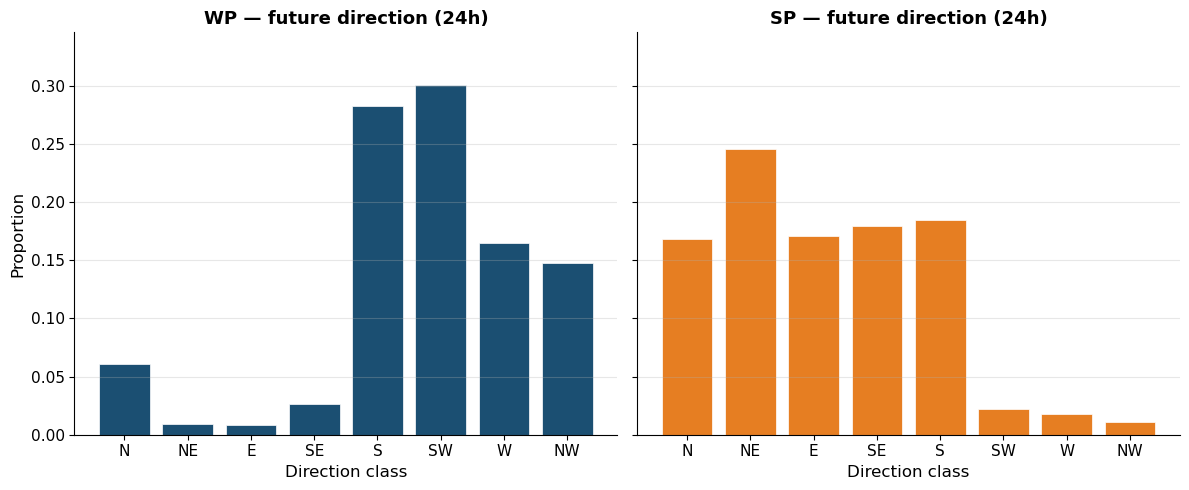

Saved direction_distribution.png


In [17]:
import seaborn as sns

DIR_LABELS = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
WP_COLOR = "#1b4f72"
SP_COLOR = "#e67e22"

def load_env_labels(basin):
    """Load future_direction24 and future_inte_change24 for all samples in a basin."""
    dirs, intens = [], []
    env_root = TCND_ROOT / "Env-Data" / basin
    for npy_path in sorted(env_root.rglob("*.npy")):
        d = np.load(npy_path, allow_pickle=True).item()
        dirs.append(int(d["future_direction24"]))
        intens.append(int(d["future_inte_change24"]))
    return np.array(dirs), np.array(intens)

wp_dirs, wp_intens = load_env_labels("WP")
sp_dirs, sp_intens = load_env_labels("SP")
print(f"Loaded WP: {len(wp_dirs)} samples, SP: {len(sp_dirs)} samples")

# CHANGED: FILTER OUT -1 SENTINEL VALUES (USED FOR MISSING DATA AT START OF STORM TRACKS)
wp_dirs_valid = wp_dirs[wp_dirs >= 0]
sp_dirs_valid = sp_dirs[sp_dirs >= 0]
wp_intens_valid = wp_intens[wp_intens >= 0]
sp_intens_valid = sp_intens[sp_intens >= 0]
print(f"After filtering -1 sentinels: WP dirs={len(wp_dirs_valid)}, SP dirs={len(sp_dirs_valid)}")
print(f"  WP intens={len(wp_intens_valid)}, SP intens={len(sp_intens_valid)}")

# proportions
wp_dir_prop = np.bincount(wp_dirs_valid, minlength=8) / len(wp_dirs_valid)
sp_dir_prop = np.bincount(sp_dirs_valid, minlength=8) / len(sp_dirs_valid)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ax1.bar(DIR_LABELS, wp_dir_prop, color=WP_COLOR, edgecolor="white", linewidth=0.5)
ax1.set_title("WP — future direction (24h)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Proportion", fontsize=12)
ax1.set_xlabel("Direction class", fontsize=12)
ax1.set_ylim(0, max(wp_dir_prop.max(), sp_dir_prop.max()) * 1.15)

ax2.bar(DIR_LABELS, sp_dir_prop, color=SP_COLOR, edgecolor="white", linewidth=0.5)
ax2.set_title("SP — future direction (24h)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Direction class", fontsize=12)

for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=11)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("direction_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved direction_distribution.png")

## 13. [DRAFT] Intensity change label distribution — WP vs SP

The `future_inte_change24` label has 4 classes. Unlike direction, intensity dynamics are governed more by thermodynamics (SST, vertical wind shear) than by hemisphere, so the distributions should look more similar between basins.

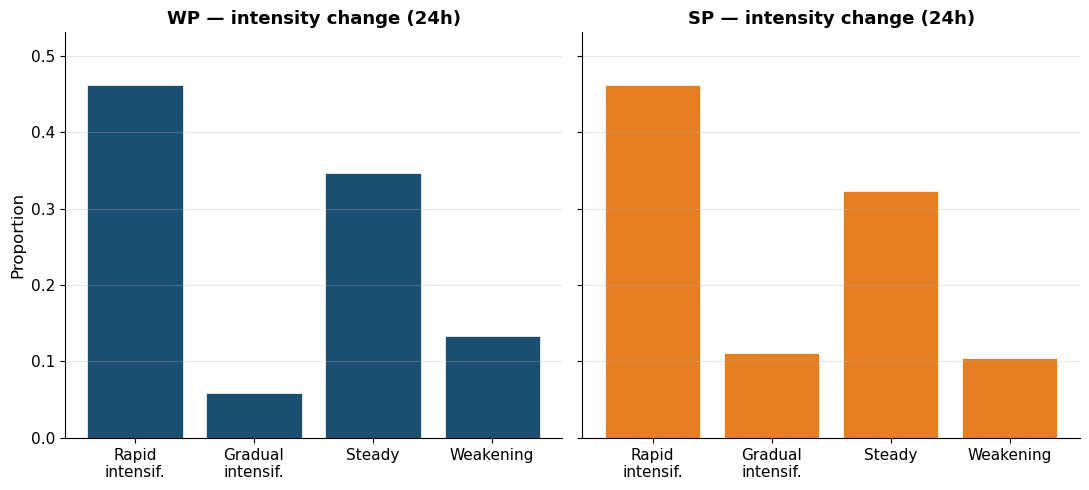

Saved intensity_distribution.png

Intensity change class proportions:
  RI: WP=0.461  SP=0.461
  Grad. intens.: WP=0.059  SP=0.111
  Steady: WP=0.347  SP=0.323
  Weakening: WP=0.134  SP=0.105


In [18]:
# Inspect what the 4 intensity change classes mean
# Class meaning inferred from the history_inte_change24 one-hot (4,) and physical context:
# 0 = rapid intensification, 1 = gradual intensification, 2 = steady/neutral, 3 = weakening
# (verify by checking correlation with actual wind changes later if needed)
INTE_LABELS = ["Rapid\nintensif.", "Gradual\nintensif.", "Steady", "Weakening"]

# CHANGED: USE THE FILTERED ARRAYS (wp_intens_valid / sp_intens_valid) INSTEAD OF RAW ONES
wp_int_prop = np.bincount(wp_intens_valid, minlength=4) / len(wp_intens_valid)
sp_int_prop = np.bincount(sp_intens_valid, minlength=4) / len(sp_intens_valid)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

ax1.bar(INTE_LABELS, wp_int_prop, color=WP_COLOR, edgecolor="white", linewidth=0.5)
ax1.set_title("WP — intensity change (24h)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Proportion", fontsize=12)
ax1.set_ylim(0, max(wp_int_prop.max(), sp_int_prop.max()) * 1.15)

ax2.bar(INTE_LABELS, sp_int_prop, color=SP_COLOR, edgecolor="white", linewidth=0.5)
ax2.set_title("SP — intensity change (24h)", fontsize=13, fontweight="bold")

for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=11)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("intensity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved intensity_distribution.png")

# print numeric comparison
print("\nIntensity change class proportions:")
for i, lbl in enumerate(["RI", "Grad. intens.", "Steady", "Weakening"]):
    print(f"  {lbl}: WP={wp_int_prop[i]:.3f}  SP={sp_int_prop[i]:.3f}")

## 14. [DRAFT] Storm track map — WP vs SP

All tracks for both basins on a single Pacific-centred map. WP tracks curve poleward in the Northern Hemisphere, SP tracks curve poleward in the Southern Hemisphere — roughly a mirror image.

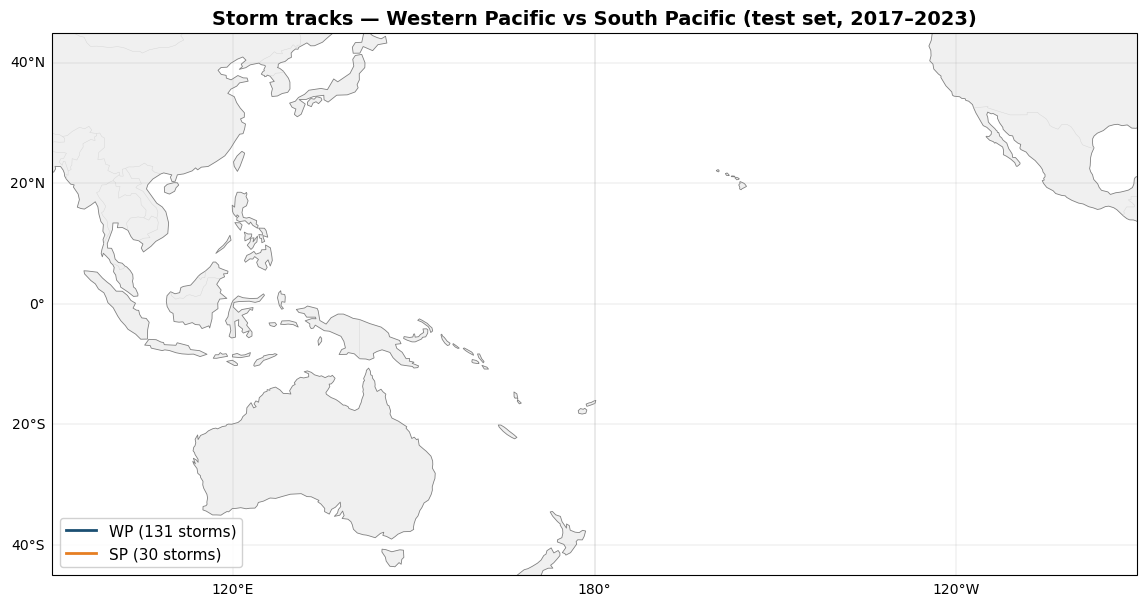

Saved track_map.png


In [19]:
wp_1d = df_1d[df_1d["basin"] == "WP"].copy()
sp_1d = df_1d[df_1d["basin"] == "SP"].copy()

fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([90, 270, -45, 45], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.6, color="grey")
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0", zorder=0)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="lightgrey")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4, color="grey")
gl.top_labels = False
gl.right_labels = False

# plot individual tracks
for name, grp in wp_1d.groupby("Name"):
    grp = grp.sort_values("ID")
    ax.plot(grp["lon_deg"], grp["lat_deg"], linewidth=0.7, alpha=0.5,
            color=WP_COLOR, transform=ccrs.PlateCarree())

for name, grp in sp_1d.groupby("Name"):
    grp = grp.sort_values("ID")
    ax.plot(grp["lon_deg"], grp["lat_deg"], linewidth=0.7, alpha=0.5,
            color=SP_COLOR, transform=ccrs.PlateCarree())

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color=WP_COLOR, lw=2, label=f"WP ({wp_1d['Name'].nunique()} storms)"),
    Line2D([0], [0], color=SP_COLOR, lw=2, label=f"SP ({sp_1d['Name'].nunique()} storms)"),
]
ax.legend(handles=handles, loc="lower left", fontsize=11, framealpha=0.9)
ax.set_title("Storm tracks — Western Pacific vs South Pacific (test set, 2017–2023)",
             fontsize=14, fontweight="bold")

plt.savefig("track_map.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved track_map.png")

## 15. [DRAFT] Side-by-side wind field comparison

Pick one intense WP and one intense SP storm, plot 850 hPa wind speed + quiver arrows. The cyclonic rotation should be visible: counterclockwise in WP (Northern Hemisphere), clockwise in SP (Southern Hemisphere).

WP storm: TCND_MANGKHUT_2018091112_sst_z_u_v.nc
SP storm: TCND_HAROLD_2020040606_sst_z_u_v.nc


/var/folders/pr/6w53n6wj66l856vz6b4j6g140000gn/T/ipykernel_18028/1790392793.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


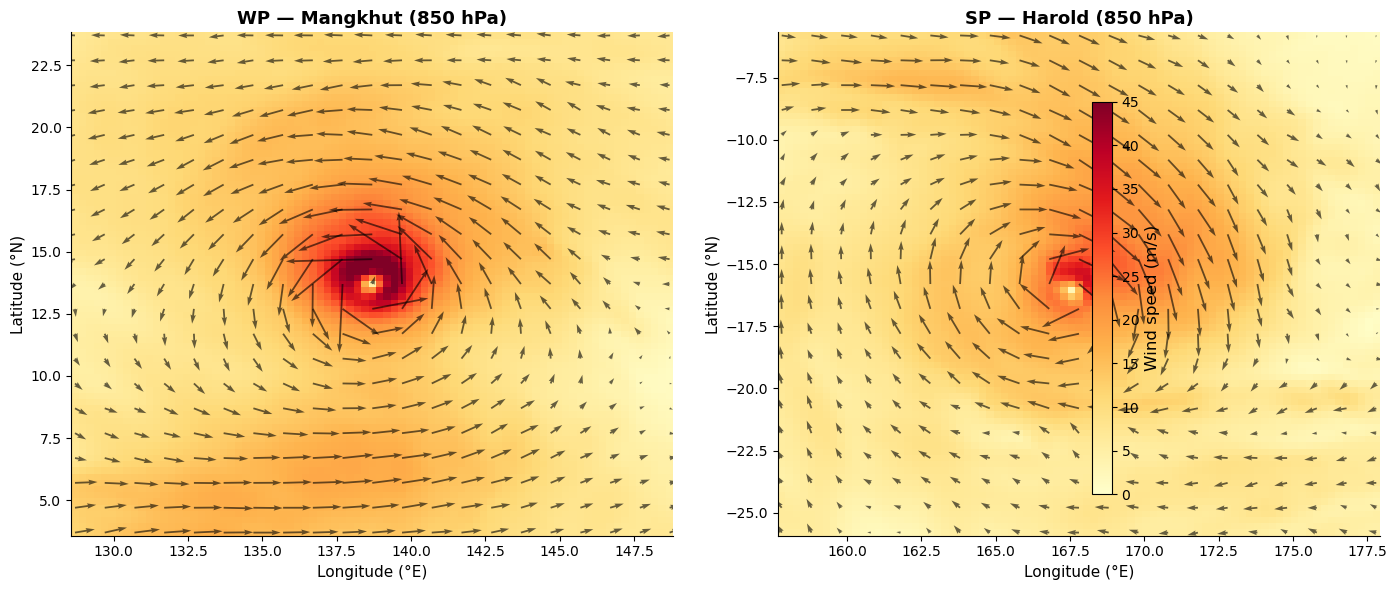

Saved wind_field_comparison.png


In [20]:
# Selected storms (both intense, clear cyclonic structure)
# WP: Mangkhut at peak intensity, SP: Harold at peak intensity
wp_nc_path = TCND_ROOT / "Data3D/WP/2018/MANGKHUT/TCND_MANGKHUT_2018091112_sst_z_u_v.nc"
sp_nc_path = TCND_ROOT / "Data3D/SP/2020/HAROLD/TCND_HAROLD_2020040606_sst_z_u_v.nc"

# fallback: find actual files if exact names differ
if not wp_nc_path.exists():
    wp_nc_path = sorted((TCND_ROOT / "Data3D/WP/2018/MANGKHUT").glob("*.nc"))[20]
if not sp_nc_path.exists():
    sp_candidates = sorted((TCND_ROOT / "Data3D/SP/2020/HAROLD").glob("*.nc"))
    sp_nc_path = sp_candidates[len(sp_candidates)//2]

print(f"WP storm: {wp_nc_path.name}")
print(f"SP storm: {sp_nc_path.name}")

ds_wp = xr.open_dataset(wp_nc_path)
ds_sp = xr.open_dataset(sp_nc_path)

# 850 hPa is pressure_level index 2 (levels: 200, 500, 850, 925)
PLI = 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, ds, title, color in [
    (ax1, ds_wp, "WP — Mangkhut (850 hPa)", WP_COLOR),
    (ax2, ds_sp, "SP — Harold (850 hPa)", SP_COLOR),
]:
    u = ds["u"].isel(time=0, pressure_level=PLI).values
    v = ds["v"].isel(time=0, pressure_level=PLI).values
    speed = np.sqrt(u**2 + v**2)
    lon = ds["longitude"].values
    lat = ds["latitude"].values

    im = ax.pcolormesh(lon, lat, speed, cmap="YlOrRd", shading="auto", vmin=0, vmax=45)
    # quiver — subsample for readability
    skip = 4
    ax.quiver(lon[::skip], lat[::skip], u[::skip, ::skip], v[::skip, ::skip],
              scale=350, width=0.003, color="black", alpha=0.6)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Longitude (°E)", fontsize=11)
    ax.set_ylabel("Latitude (°N)", fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# shared colourbar
cbar = fig.colorbar(im, ax=[ax1, ax2], shrink=0.85, pad=0.02)
cbar.set_label("Wind speed (m/s)", fontsize=12)

plt.tight_layout()
plt.savefig("wind_field_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved wind_field_comparison.png")